# ❗ 6. SKHynix PBL XAI 적용 - 머신러닝 모델❗


## 📌 개요

학습 완료된 머신러닝과 딥러닝 모델로부터 XAI 기법 적용하여 주요 변수 찾기

**데이터 입력 구조 및 XAI 해석 방식**:
- **머신러닝 모델**:  
    - 앙상블 계열 모델 내부 변수 별 중요도는 그 자체로 판단
    - SHAP value: 예측값이 증가/감소 하는데 영향을 주는 변수 확인
- **딥러닝 모델**: 예측값이 증가/감소 하는데 영향을 주는 전체 입력 값 중 특정 위치의 oper_id (만약 special 토큰 추가 시, special 토큰도 해당 될 수 있음)

**주요 사항**:
- **머신러닝 모델**:
    - 기본적으로 scikit-learn 제공 모델 대상으로 진행됨
    - 앙상블 계열 모델(ex. Random Forest, GBM, AdaBoost 등) 자체적으로 변수 별 중요도 산출 가능함
    - XAI 기법 중 하나인 SHAP을 이용하여 확인
        - SHAP으로 앙상블 계열 모델에 대해서도 적용은 가능함  
        - SHAP 공식 문서 [[LINK](https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/model_agnostic/Multioutput%20Regression%20SHAP.html)]

- **딥러닝 모델**:
    - captum의 Integrated Gradients 기반으로 수치예측에 대한 XAI 적용
    - captum 공식 문서[[LINK](https://captum.ai/)]

- **공통사항**
    - 딥러닝,머신러닝 모델 모두 학습이 완료된 것을 가정함 / 학습 완료된 모델 필요함

## 🔧 1. 환경 설정 및 라이브러리 준비

### SHAP, Captum 설치 필요

```python
pip install shap
pip install captum
```

In [1]:
"""사용 라이브러리"""
from typing import List, Dict, Tuple, Optional, Union
from types import SimpleNamespace
from collections import defaultdict
from datetime import datetime
import time
import os
import json
import argparse
import math
import warnings
import logging

# ====================
# 데이터 처리 및 분석
# ====================
import yaml
import pandas as pd
import numpy as np

# ====================
# 시각화
# ====================
import matplotlib.pyplot as plt
import seaborn as sns

# ====================
# 머신러닝 - 데이터 전처리
# ====================
from sklearn.preprocessing import (
    LabelEncoder, 
    OneHotEncoder,
    StandardScaler, 
    MinMaxScaler, 
    RobustScaler
)

# ====================
# 머신러닝 - 모델
# ====================
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    AdaBoostRegressor
)
import xgboost
import lightgbm

# ====================
# 머신러닝 - 모델 평가 및 선택
# ====================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

# ====================
# PyTorch
# ====================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR

# ====================
# XAI 라이브러리
# ====================
import shap
import captum

# ====================
# 진행상황 표시
# ====================
from tqdm import tqdm

# 경고 메시지 제어
warnings.filterwarnings('ignore')

/usr/local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 🥊 기본 cofiguration 설정

In [2]:
def load_config(config_dir: str = "configs") -> Dict:
    """YAML 설정 파일들을 통합하여 로드"""
    configs = {}
    config_files = ["dataset", "model", "training"]

    for file in config_files:
        config_path = os.path.join(config_dir, f"{file}.yaml")
        with open(config_path, "r", encoding="utf-8") as f:
            config = yaml.safe_load(f)
            configs.update(config)

    return configs


def set_random_seeds(seed: int = 42):
    """재현성을 위한 랜덤 시드 설정"""
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def setup_logging(log_file: str = "training.log"):
    """로깅 설정"""
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s - %(levelname)s - %(message)s",
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger(__name__)

import os
import argparse
print(f"현재 위치:",os.getcwd())
os.chdir(os.getcwd())

parser = argparse.ArgumentParser(description="XAI 기반 주요 인자 분석")
parser.add_argument("--config-dir", default="./configs/", help="설정 파일 디렉토리")
parser.add_argument("--mode", default="eval", help="딥러닝 모델은 이미 학습이 완료된 것을 가정")
parser.add_argument("--model-path", default=None, help="평가용 모델 경로")
parser.add_argument("--gpu", type=int, default=0, help="GPU 번호")
parser.add_argument("--exp-name", default=None, help="실험명")

args = parser.parse_args([])


# 설정 로드
config = load_config(args.config_dir)
set_random_seeds(42)

# 실험명 설정
if args.exp_name:
    exp_name = args.exp_name
else:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_type = config.get("model_type", "default_model")
    exp_name = f"{model_type}_{timestamp}"

# 저장 디렉토리
save_dir = os.path.join("results", config.get("save_dir", "default"))
os.makedirs(save_dir, exist_ok=True)

# logger 설정
logger = setup_logging(os.path.join(save_dir, config.get("log_file", "training.log")))


현재 위치: /home/doyoon/teaching/SKhynix_2025/SKhynix_week6


# 🚥데이터셋 전처리

In [3]:
class CategoricalProcessor:
    """범주형 변수 임베딩을 위한 처리기"""
    
    def __init__(self, embedding_dim: int = 8):
        self.embedding_dim = embedding_dim
        self.label_encoders = {}
        self.vocab_sizes = {}
        self.categorical_columns = []
        
    def fit(self, df: pd.DataFrame, categorical_columns: List[str]):
        """전체 데이터에 대해 범주형 인코더 학습"""
        self.categorical_columns = categorical_columns
        
        for col in categorical_columns:
            unique_values = df[col].astype(str).unique()
            encoder = LabelEncoder()
            encoder.fit(unique_values)
            
            self.label_encoders[col] = encoder
            self.vocab_sizes[col] = len(encoder.classes_)
        
        logger.info(f"범주형 변수별 고유값 개수:")
        for col in categorical_columns:
            logger.info(f"  {col}: {self.vocab_sizes[col]}개")
    
    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """DataFrame의 범주형 컬럼들을 숫자로 변환"""
        df_encoded = df.copy()
        
        for col in self.categorical_columns:
            df_encoded[col] = self.label_encoders[col].transform(
                df_encoded[col].astype(str)
            )
        
        return df_encoded
    
    def get_vocab_sizes(self) -> List[int]:
        """각 범주형 변수의 vocab_size 리스트 반환"""
        return [self.vocab_sizes[col] for col in self.categorical_columns]

In [4]:
def split_data_by_days(
    df: pd.DataFrame,  # 입력 데이터프레임
    train_ratio: float = 0.8,  # 학습 데이터 비율
    val_ratio: float = 0.1,  # 검증 데이터 비율
    test_ratio: float = 0.1  # 테스트 데이터 비율
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """날짜 기준으로 데이터를 분할"""
    
    # timekey_hr에서 날짜(day) 추출 (시간 정보 제거)
    # 예: 20240115 -> 202401 (년월 추출)
    df['date'] = (df['timekey_hr'].astype(int) // 100).astype(int)
    
    # 고유한 날짜들을 시간순으로 정렬
    unique_dates = sorted(df['date'].unique())
    total_days = len(unique_dates)  # 전체 날짜 수
    
    # 날짜 기준으로 분할 인덱스 계산
    train_days = int(total_days * train_ratio)  # 학습용 날짜 수
    val_days = int(total_days * val_ratio)  # 검증용 날짜 수
    
    # 각 분할에 해당하는 날짜 범위 설정
    train_dates = unique_dates[:train_days]  # 처음부터 train_days까지
    val_dates = unique_dates[train_days:train_days + val_days]  # train 다음부터 val_days개
    test_dates = unique_dates[train_days + val_days:]  # 나머지 모든 날짜
    
    # 각 분할에 해당하는 데이터 추출
    train_df = df[df['date'].isin(train_dates)].copy()  # 학습 데이터
    val_df = df[df['date'].isin(val_dates)].copy()  # 검증 데이터
    test_df = df[df['date'].isin(test_dates)].copy()  # 테스트 데이터
    
    # 분할 결과 정보 로깅
    logger.info(f"날짜 기준 데이터 분할 완료:")
    logger.info(f"  - 총 날짜 수: {total_days}일")
    logger.info(f"  - Train: {len(train_dates)}일 ({len(train_df):,}행)")
    logger.info(f"  - Validation: {len(val_dates)}일 ({len(val_df):,}행)")  
    logger.info(f"  - Test: {len(test_dates)}일 ({len(test_df):,}행)")
    logger.info(f"  - Train 날짜 범위: {min(train_dates)} ~ {max(train_dates)}")
    logger.info(f"  - Val 날짜 범위: {min(val_dates)} ~ {max(val_dates)}")
    logger.info(f"  - Test 날짜 범위: {min(test_dates)} ~ {max(test_dates)}")
    
    # 학습, 검증, 테스트 데이터프레임 반환
    return train_df, val_df, test_df


In [5]:
# 데이터 로드 및 전처리
data_path = config["file_path"]  # 설정에서 파일 경로 가져오기
# nrows는 테스트용이므로 꼭 제거 ! (주의사항 메모)
# Excel 파일의 모든 시트를 딕셔너리로 읽기, 두 번째 행을 헤더로 사용
excel = pd.read_excel(data_path, sheet_name=None, header=1)
sheet_names = config["sheet_names"]  # 사용할 시트 이름 목록 가져오기

# # # 지정된 시트들의 데이터를 하나의 데이터프레임으로 결합
total_df = pd.concat([excel[sheet_name] for sheet_name in sheet_names])

# 각 그룹(oper_group)별로 속한 공정(oper_id)들의 고유 값을 딕셔너리로 생성
group_to_opers = total_df.groupby('oper_group')['oper_id'].unique().to_dict()
# 전체 고유 그룹 수 계산
unique_groups_num = len(total_df['oper_group'].unique().tolist())

# 기본 전처리
# "Unnamed: 0" 컬럼이 있으면 제거 (Excel 읽기 시 생성되는 인덱스 컬럼)
if "Unnamed: 0" in total_df.columns:
    total_df.drop(columns="Unnamed: 0", inplace=True)

# y값 결측치 제거
# 타겟 컬럼에 결측치가 없는 행만 선택하여 복사본 생성
df = total_df[~total_df[config["target_column"]].isna()].copy()
# y 값이 0인 경우 제거
df = df[df[config["target_column"]] > 0].copy()

# 사용하고자 하는 컬럼들만 선택
df = df[["timekey_hr"]+config["categorical_columns"]+config["continuous_columns"]+ [config["target_column"]]]


# 인덱스 재설정 (0부터 시작하는 연속 인덱스로 변경)
df.reset_index(drop=True, inplace=True)

# ========================================
# 데이터 전처리 (정규화 전): NaN, Inf 제거
# ========================================

continuous_columns = config["continuous_columns"]
categorical_columns = config["categorical_columns"]
target_column = config["target_column"]
input_columns = config["continuous_columns"] + config["categorical_columns"]


logger.info("데이터 전처리 시작...")

# NaN 체크 및 처리
nan_count = df[continuous_columns].isna().sum().sum()
if nan_count > 0:
    logger.warning(f"연속형 변수에 {nan_count}개의 NaN 발견! 0으로 대체합니다.")
    df[continuous_columns] = df[continuous_columns].fillna(0)

# Inf 체크 및 제거
inf_mask = np.isinf(df[continuous_columns].values)
if inf_mask.any():
    logger.warning(f"Inf 값 발견! 제거합니다.")
    df[continuous_columns] = df[continuous_columns].replace([np.inf, -np.inf], np.nan)
    df[continuous_columns] = df[continuous_columns].fillna(0)
    
# ========================================
# 범주형 변수 처리 (분할 전에 전체 데이터로)
# ========================================

# 범주형 처리기는 전체 데이터로 학습 (모든 카테고리를 알아야 함)
categorical_processor = CategoricalProcessor(
    embedding_dim=config.get("embedding_dim", 8)
)
categorical_processor.fit(df, categorical_columns)
df = categorical_processor.transform(df)


# ========================================
# 데이터 분할
# ========================================

# 데이터 분할 (8:1:1)
# 날짜 기준으로 시계열 데이터를 train, validation, test로 분할
train_df, val_df, test_df = split_data_by_days(
    df,
    train_ratio=config.get("train_ratio", 0.8),  # 학습 데이터 비율 (기본값: 0.8)
    val_ratio=config.get("val_ratio", 0.1),      # 검증 데이터 비율 (기본값: 0.1)
    test_ratio=config.get("test_ratio", 0.1)      # 테스트 데이터 비율 (기본값: 0.1)
)

# ========================================
# 연속형 변수 정규화
# ========================================

logger.info("연속형 변수 정규화")

# 1. 극단값 클리핑 (각 데이터셋 별도 처리)
if config.get("clip_outliers", True):
    logger.info("극단값 클리핑 적용...")
    
    # Train 데이터의 분위수로 클리핑 범위 결정
    clip_values = {}
    for col in continuous_columns:
        q01 = train_df[col].quantile(0.01)
        q99 = train_df[col].quantile(0.99)
        clip_values[col] = (q01, q99)
        
        # 모든 데이터셋에 동일한 클리핑 적용
        train_df[col] = train_df[col].clip(q01, q99)
        val_df[col] = val_df[col].clip(q01, q99)
        test_df[col] = test_df[col].clip(q01, q99)
        
        logger.debug(f"  {col}: [{q01:.4f}, {q99:.4f}]로 클리핑")

# 2. Scaler 생성 및 학습 (train 데이터만 사용!)
scaler_type = config.get("scaler_type", "robust")

if scaler_type == "robust":
    continuous_scaler = RobustScaler()
    logger.info("RobustScaler 사용 (이상치에 강건, 중앙값과 IQR 기반)")
elif scaler_type == "standard":
    continuous_scaler = StandardScaler()
    logger.info("StandardScaler 사용 (평균 0, 표준편차 1)")
elif scaler_type == "minmax":
    # MinMaxScaler의 범위를 설정 가능하게
    feature_range = config.get("minmax_range", (0, 1))
    continuous_scaler = MinMaxScaler(feature_range=feature_range)
    logger.info(f"MinMaxScaler 사용 (범위: {feature_range[0]}~{feature_range[1]})")
else:
    logger.warning(f"알 수 없는 scaler_type: {scaler_type}. RobustScaler 사용")
    continuous_scaler = RobustScaler()

# Train 데이터로만 fit!
continuous_scaler.fit(train_df[continuous_columns])

# 모든 데이터에 transform 적용
train_df[continuous_columns] = continuous_scaler.transform(train_df[continuous_columns])
val_df[continuous_columns] = continuous_scaler.transform(val_df[continuous_columns])
test_df[continuous_columns] = continuous_scaler.transform(test_df[continuous_columns])

logger.info("Normalize done!")




# ========================================
# 최종 데이터 확인
# ========================================
logger.info("최종 데이터 확인:")
def log_data_info(df: pd.DataFrame, name: str):
    """데이터프레임의 기본 정보 로깅"""
    logger.info(f"  - {name} 데이터:")
    logger.info(f"    행 개수: {len(df):,}")
    logger.info(f"    컬럼 개수: {len(df.columns)}")
    logger.info(f"    컬럼 목록: {df.columns.tolist()}")
    logger.info(f"    결측치 개수:\n{df.isna().sum()}")

log_data_info(train_df, "Train")
log_data_info(val_df, "Validation")
log_data_info(test_df, "Test")



2025-09-14 03:22:46,037 - INFO - 데이터 전처리 시작...
2025-09-14 03:22:46,190 - WARNING - Inf 값 발견! 제거합니다.
2025-09-14 03:22:46,923 - INFO - 범주형 변수별 고유값 개수:
2025-09-14 03:22:46,923 - INFO -   oper_group: 277개
2025-09-14 03:22:46,924 - INFO -   days: 7개
2025-09-14 03:22:46,924 - INFO -   shift: 3개
2025-09-14 03:22:46,925 - INFO -   x1: 20개
2025-09-14 03:22:48,380 - INFO - 날짜 기준 데이터 분할 완료:
2025-09-14 03:22:48,381 - INFO -   - 총 날짜 수: 90일
2025-09-14 03:22:48,381 - INFO -   - Train: 72일 (1,342,783행)
2025-09-14 03:22:48,382 - INFO -   - Validation: 9일 (170,701행)
2025-09-14 03:22:48,382 - INFO -   - Test: 9일 (157,942행)
2025-09-14 03:22:48,383 - INFO -   - Train 날짜 범위: 20250503 ~ 20250713
2025-09-14 03:22:48,383 - INFO -   - Val 날짜 범위: 20250714 ~ 20250722
2025-09-14 03:22:48,384 - INFO -   - Test 날짜 범위: 20250723 ~ 20250731
2025-09-14 03:22:48,385 - INFO - 연속형 변수 정규화
2025-09-14 03:22:48,386 - INFO - StandardScaler 사용 (평균 0, 표준편차 1)
2025-09-14 03:22:48,759 - INFO - Normalize done!
2025-09-14 03:22:48,7

In [6]:
print(f"\n{'='*60}")
print(f"X, y 분리")
print(f"{'='*60}")
print(f"🎯 타겟 컬럼: {target_column}")

def split_xy_from_datasets(df_train, df_val, df_test, input_columns,
                          target_col):
    """
    Parameters:
    ----------
    df_train, df_val, df_test : pandas.DataFrame
        스케일링된 데이터셋들
    input_columns : List[str]
        입력 변수 컬럼명 리스트
    target_col : str
        타겟 컬럼명
    verbose : bool, default=True
        상세 출력 여부

    Returns:
    -------
    tuple : (X_train, X_val, X_test,
             y_train, y_val, y_test)
    """

    # 타겟 컬럼이 존재하는지 확인
    if target_col not in df_train.columns:
        raise ValueError(f"타겟 컬럼 '{target_col}'이 데이터에 없습니다.")

    # X, y 분리
    X_train = df_train.drop(columns=[target_col])[input_columns]
    X_val = df_val.drop(columns=[target_col])[input_columns]
    X_test = df_test.drop(columns=[target_col])[input_columns]

    y_train = df_train[target_col]
    y_val = df_val[target_col]
    y_test = df_test[target_col]

    print("✅ X, y 분리 완료!")

    # 결과 요약
    print(f"\n📊 분리 결과:")
    print(f"   입력 변수 개수: {len(input_columns)}")
    print(f"   X_train: {X_train.shape}")
    print(f"   X_val:   {X_val.shape}")
    print(f"   X_test:  {X_test.shape}")
    print(f"   y_train: {len(y_train)}")
    print(f"   y_val:   {len(y_val)}")
    print(f"   y_test:  {len(y_test)}")

    return (X_train, X_val, X_test,
            y_train, y_val, y_test)

(X_train, X_val, X_test,
y_train, y_val, y_test) = split_xy_from_datasets(
              train_df, val_df, test_df, input_columns, target_column
              )


X, y 분리
🎯 타겟 컬럼: y
✅ X, y 분리 완료!

📊 분리 결과:
   입력 변수 개수: 24
   X_train: (1342783, 24)
   X_val:   (170701, 24)
   X_test:  (157942, 24)
   y_train: 1342783
   y_val:   170701
   y_test:  157942


# 📐 모델 설정 및 학습

In [ ]:
print("\n" + "="*60)
print("각 모델 알고리즘 & 앙상블 구현")
print("="*60)

# 파스텔 색상 팔레트 정의
pastel_colors = {
    'blue': '#AED6F1',
    'green': '#A9DFBF',
    'pink': '#F5B7B1',
    'purple': '#D2B4DE',
    'orange': '#F8C471',
    'coral': '#F1948A',
    'mint': '#A3E4D7',
    'yellow': '#F9E79F'
}

# 알고리즘 정의
algorithms = {}

# 1. 기본 의사결정나무
algorithms['Decision Tree'] = DecisionTreeRegressor(
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10
)

# 2. 랜덤 포레스트
algorithms['Random Forest'] = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    n_jobs=-1
)


# 3. 그래디언트 부스팅
algorithms['Gradient Boosting'] = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8
)

# 4. AdaBoost (의사결정나무 기반)
algorithms['AdaBoost'] = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=6, random_state=42),
    n_estimators=100,
    random_state=42,
    learning_rate=1.0
)

# 5. XGBoost
algorithms['XGBoost'] = xgboost.XGBRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    eval_metric='rmse',
    verbosity=0  # 출력 최소화
)

# 6. LightGBM
algorithms['LightGBM'] = lightgbm.LGBMRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='regression',
    metric='rmse',
    verbosity=-1,  # 출력 최소화
    force_row_wise=True  # 경고 방지
)


# 모델 훈련 및 평가
results = {}
trained_models = {}

for name, model in algorithms.items():
    print(f"\n🔄 {name} 훈련 중...")

    # 모델 훈련
    model.fit(X_train, y_train)
    trained_models[name] = model

    # 예측
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    # 평가 지표 계산
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_mae = mean_absolute_error(y_train, train_pred)
    val_mae = mean_absolute_error(y_val, val_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_mape = mean_absolute_percentage_error(y_train, train_pred)
    val_mape = mean_absolute_percentage_error(y_val, val_pred)
    test_mape = mean_absolute_percentage_error(y_test, test_pred)


    results[name] = {
        'train_mae': train_mae,
        'val_mae': val_mae,
        'test_mae': test_mae,
        'train_mape': train_mape,
        'val_mape': val_mape,
        'test_mape': test_mape,
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'test_rmse': test_rmse
    }

    print(f"✅ {name} 완료!")
    print(f"   Train MAE: {train_mae:.4f}, Val MAE: {val_mae:.4f}, Test MAE: {test_mae:.4f}")
    print(f"   Train MAPE: {train_mape:.4f}, Val MAPE: {val_mape:.4f}, Test MAPE: {test_mape:.4f}")
    print(f"   Train RMSE: {np.sqrt(train_mse):.4f}, Val RMSE: {np.sqrt(val_mse):.4f}, Test RMSE: {np.sqrt(test_mse):.4f}")


In [58]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='test_mape')
col_order = ['train_mape', 'val_mape', 'test_mape',
            'train_mae', 'val_mae', 'test_mae', 
             'train_rmse', 'val_rmse', 'test_rmse']
results_df = results_df[col_order]
print("\n📊 모델별 성능 비교:")
display(results_df)


📊 모델별 성능 비교:


,train_mape,val_mape,test_mape,train_mae,val_mae,test_mae,train_rmse,val_rmse,test_rmse
XGBoost,0.526494,0.562315,0.553808,0.049715,0.052885,0.052713,0.136727,0.139392,0.153386
LightGBM,0.533805,0.572333,0.558459,0.050340,0.053241,0.052896,0.140297,0.140653,0.152525
Gradient Boosting,0.543428,0.575778,0.565182,0.050024,0.053472,0.053230,0.130148,0.142723,0.154123
Random Forest,0.540039,0.588391,0.566680,0.050084,0.053988,0.053038,0.138254,0.143192,0.151420
Decision Tree,0.543495,0.594919,0.570689,0.051113,0.055972,0.053850,0.141066,0.152162,0.156347
AdaBoost,12.829983,11.894705,11.505385,0.596655,0.596645,0.592257,0.626545,0.628903,0.627733


## 학습 완료된 모델 저장

- scikit-learn의 모델들은 주로 pkl(pickle) 파일로 저장됨
- 저장/불러오기 모두 pickle 라이브러리 통해 진행됨


In [59]:
import pickle

# 모델 저장
for name, model in trained_models.items():
    model_path = os.path.join(save_dir, f"{name.replace(' ', '_').lower()}_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"💾 {name} 모델 저장 완료: {model_path}")

💾 Decision Tree 모델 저장 완료: results/250913_test/decision_tree_model.pkl
💾 Random Forest 모델 저장 완료: results/250913_test/random_forest_model.pkl
💾 Gradient Boosting 모델 저장 완료: results/250913_test/gradient_boosting_model.pkl
💾 AdaBoost 모델 저장 완료: results/250913_test/adaboost_model.pkl
💾 XGBoost 모델 저장 완료: results/250913_test/xgboost_model.pkl
💾 LightGBM 모델 저장 완료: results/250913_test/lightgbm_model.pkl


# 학습 완료된 모델 불러오기

- scikit-learn의 모델들은 주로 pkl(pickle) 파일로 저장됨
- 저장/불러오기 모두 pickle 라이브러리 통해 진행됨


In [9]:
import pickle
model_names = ['Decision Tree', 'Random Forest', 'Gradient Boosting', 
               'AdaBoost', 'XGBoost', 'LightGBM']
loaded_models = {}
results = {}
for name in model_names:
    model_path = os.path.join(save_dir, f"{name.replace(' ', '_').lower()}_model.pkl")
    with open(model_path, "rb") as f:
        model = pickle.load(f)
        loaded_models[name] = model
    
    test_pred = model.predict(X_test)
    
    test_mae = mean_absolute_error(y_test, test_pred)
    test_mape = mean_absolute_percentage_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    results[name] = {
        
        'test_mae': test_mae,
        'test_mape': test_mape,
        'test_rmse': test_rmse
    }
    print(f"✅ {name} 모델 로드 및 평가 완료!")
    

✅ Decision Tree 모델 로드 및 평가 완료!
✅ Random Forest 모델 로드 및 평가 완료!
✅ Gradient Boosting 모델 로드 및 평가 완료!
✅ AdaBoost 모델 로드 및 평가 완료!
✅ XGBoost 모델 로드 및 평가 완료!
✅ LightGBM 모델 로드 및 평가 완료!


# 앙상블 모델 내무 변수 중요도 산출

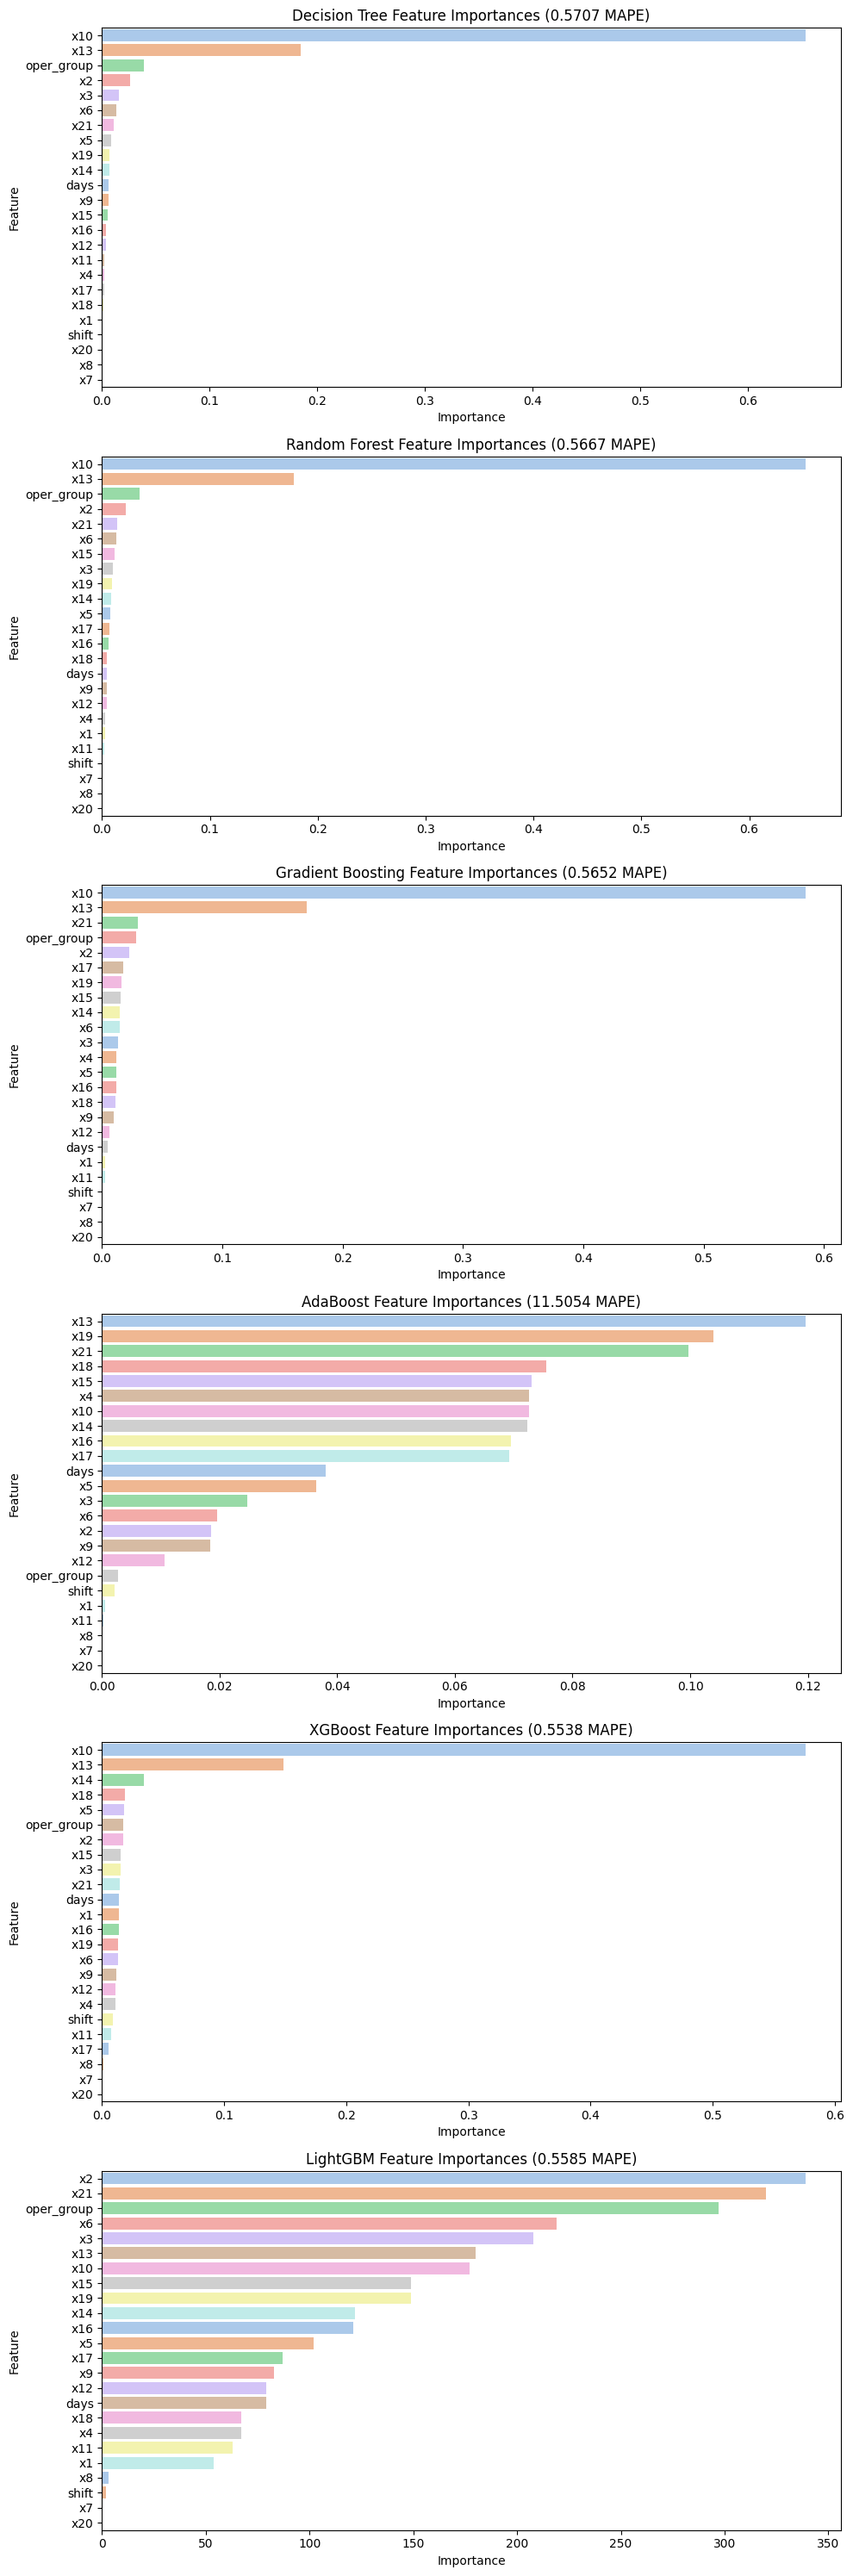

In [10]:
from collections import defaultdict

feature_importances = {}
for name, model in loaded_models.items():
    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = model.feature_importances_
    else:
        print(f"⚠️ {name} 모델은 feature_importances_ 속성이 없습니다.")

# 특성 중요도 시각화, ranking
ranked_features = defaultdict(list)

plt.figure(figsize=(10, 30))
for i, (name, importances) in enumerate(feature_importances.items()):
    indices = np.argsort(importances)[::-1]
    sorted_importances = importances[indices]
    sorted_features = []
    for rank, idx in enumerate(indices):
        sorted_features.append(X_train.columns[idx])   
        ranked_features[X_train.columns[idx]].append(1/(rank+1))
    plt.subplot(len(feature_importances), 1, i + 1)
    sns.barplot(x=sorted_importances, y=sorted_features, palette="pastel")
    plt.title(f"{name} Feature Importances ({results[name]['test_mape']:.4f} MAPE)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

ranked_features_avg = {feat: np.mean(ranks) for feat, ranks in ranked_features.items()}

### 종합 결과

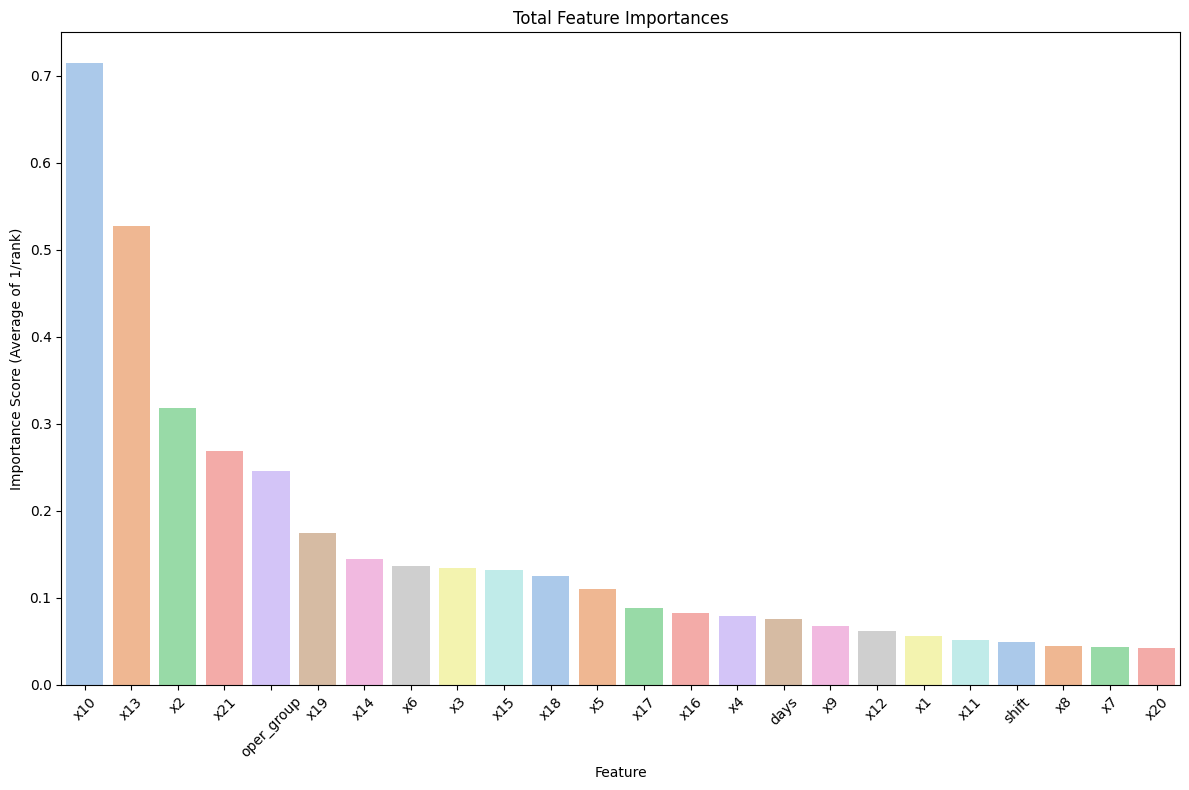

In [11]:
plt.figure(figsize=(12, 8))
# dictionary를 중요도 순으로 정렬
ranked_features_avg = dict(sorted(ranked_features_avg.items(), key=lambda item: item[1], reverse=True))
sns.barplot(y=ranked_features_avg.values(), x=ranked_features_avg.keys(), palette="pastel",)
plt.title(f"Total Feature Importances")
plt.ylabel("Importance Score (Average of 1/rank)")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.tight_layout()

# 🏁 SHAP 적용하기
- KernelSHAP 활용(shap 라이브러리 상: `KernelExplainer`)
- 훈련용, 시험용 데이터에서 모든 데이터를 활용하지 않고 일부만 활용해서 explainer를 fitting 시킨 후 SHAPvalue 획득
    - 모든 데이터를 활용하는 것이 가장 이상적이지만, 그러한 경우 계산 시간이 굉장히 많이 소비됨
- 훈련용 데이터에서는 kmeans 클러스터링 통해 대표적인 샘플 획득
- 시험용 데이터에서는 임의로 선정
- 각각 700개 씩 선택

In [69]:
# shap.initjs()
from tqdm import tqdm

# SHAP 관련 로깅 비활성화
logging.getLogger('shap').setLevel(logging.WARNING)
logging.getLogger().setLevel(logging.WARNING)

# 경고 메시지도 숨기기
warnings.filterwarnings('ignore')


shap_values_dict = {}

sampled_train = shap.kmeans(X_train, 700)
# sampled_train = shap.sample(X_train, min(700, len(X_train)),random_state=2025)
sampled_test = X_test.sample(n=min(700, len(X_test)), random_state=2025)

for name, model in tqdm(loaded_models.items(),desc = "Calculating SHAP values for models", ncols=100, unit="model"):
    try:
        print(f"\n🔄 {name} 모델에 대한 SHAP 값 계산 중...")
        ex = shap.KernelExplainer(model.predict, sampled_train, link="identity", seed=2025, silent=True)
        shap_values = ex.shap_values(X=sampled_test, nsamples=10)
        # shap.force_plot(ex.expected_value, shap_values, sampled_test, input_columns, out_names=target_column)
        shap_values_dict[name] = {'df': pd.DataFrame(shap_values, columns=input_columns), 'values': shap_values}
        print(f"✅ {name} 모델 KernelSHAP 값 계산 완료.")
    except Exception as e:
        print(f"⚠️ {name} 모델에 대한 SHAP 값 계산 중 오류 발생: {e}")
        print(f" TresExplainer로 시도합니다...")
        try:
            ex = shap.TreeExplainer(model)
            shap_values = ex.shap_values(sampled_test)
            shap_values_dict[name] = {'df': pd.DataFrame(shap_values, columns=input_columns), 'values': shap_values}
            print(f"✅ {name} 모델 TreeSHAP 값 계산 완료.")
        except Exception as e2:
            print(f"⚠️ {name} 모델에 대한 TreeExplainer 시도 중 오류 발생: {e2}")

Calculating SHAP values for models:   0%|                                  | 0/6 [00:00<?, ?model/s]2025-09-14 07:34:17,855 - WARNING - Using 700 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.



🔄 Decision Tree 모델에 대한 SHAP 값 계산 중...


Calculating SHAP values for models:  17%|████▎                     | 1/6 [00:04<00:23,  4.63s/model]2025-09-14 07:34:22,534 - WARNING - Using 700 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


✅ Decision Tree 모델 KernelSHAP 값 계산 완료.

🔄 Random Forest 모델에 대한 SHAP 값 계산 중...


Calculating SHAP values for models:  33%|████████▋                 | 2/6 [01:04<02:27, 36.89s/model]2025-09-14 07:35:21,967 - WARNING - Using 700 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


...

✅ Gradient Boosting 모델 KernelSHAP 값 계산 완료.

🔄 AdaBoost 모델에 대한 SHAP 값 계산 중...


Calculating SHAP values for models:  83%|█████████████████████▋    | 5/6 [02:13<00:24, 24.63s/model]

✅ AdaBoost 모델 KernelSHAP 값 계산 완료.

🔄 XGBoost 모델에 대한 SHAP 값 계산 중...
⚠️ XGBoost 모델에 대한 SHAP 값 계산 중 오류 발생: can't set attribute
 TresExplainer로 시도합니다...
✅ XGBoost 모델 TreeSHAP 값 계산 완료.

🔄 LightGBM 모델에 대한 SHAP 값 계산 중...
⚠️ LightGBM 모델에 대한 SHAP 값 계산 중 오류 발생: can't set attribute
 TresExplainer로 시도합니다...


Calculating SHAP values for models: 100%|██████████████████████████| 6/6 [02:14<00:00, 22.34s/model]

✅ LightGBM 모델 TreeSHAP 값 계산 완료.


## 시각화 통한 변수 별 영향력 확인
* SHAP 공식 문서 [[LINK](https://shap.readthedocs.io/en/latest/example_notebooks/api_examples/plots/bar.html)]

### 1) SHAP value의 절대값 통한 영향력 자체의 확인
**시각화 결과물 해석**
- 변수 별 예측 변수 값의 예측에 영향을 주는 정도로 일차적인 확인 가능  
    - ex) X10이 가장 영향력이 큰 것을 알 수 있음 / 이는 앞선 모델 자체의 변수 중요도의 결과와 일맥상통함

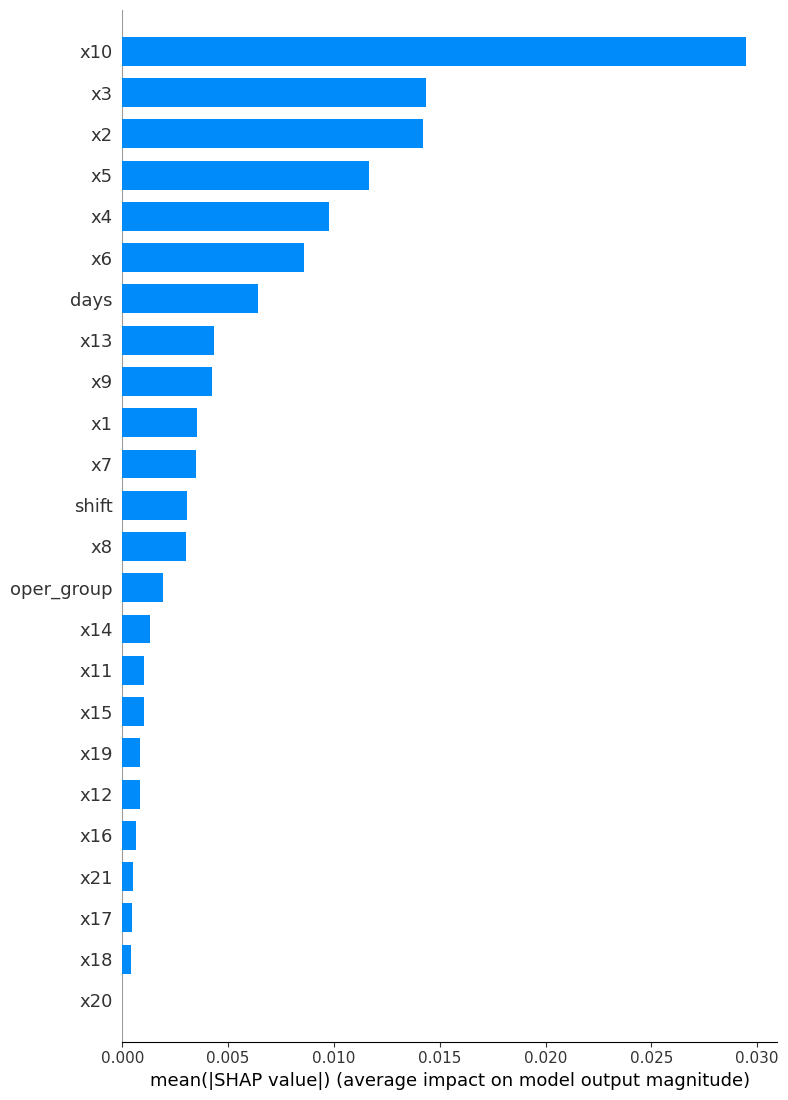

In [70]:
name = 'Random Forest'
shap_values = shap_values_dict[name]['values']
shap.summary_plot(shap_values, sampled_test, feature_names=input_columns, plot_type="bar", max_display=len(input_columns))

### 2) 변수의 증감에 따른 예측 값의 변화 확인
**시각화 결과물 해석**
- 1)의 결과물과 함께 보았을 때, SHAP value 자체가 0에 가까울 수록 영향력이 크지 않은 변수임
- 변수의 값과 SHAP value의 관계  
    - 변수의 값 = 붉은색, SHAP value >0 → 변수의 값이 클수록 예측값이 커진다
    - 변수의 값 = 파란색, SHAP value >0 → 변수의 값이 작을수록 예측값이 커진다
    - ex) X10: 붉은색 점들의 SHAP value가 0보다 큰쪽에 많이 위치함  
        = X10의 값이 커질수록 TAT 값이 크게 예측된다
    - ex) X7: 대부분이 파란색 점, SHAP value가 0에 모여 있지만, 양의 SHAP value가 음의 SHAP value보다 더 분포  
        = X7의 값의 분포가 극도로 치우쳐져 있으며, SHAP value가 0보다 큰 쪽이 많으므로 값이 커질수록 TAT 값이 크게 예측됨

count    700.000000
mean      -0.035463
std        0.649398
min       -0.089064
25%       -0.089064
50%       -0.089064
75%       -0.089064
max       10.899208
Name: x7, dtype: float64

<Axes: title={'center': 'x7 distribution'}, ylabel='Frequency'>

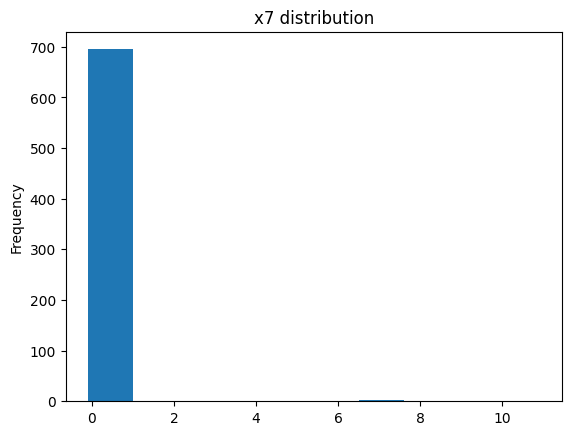

In [72]:
display(sampled_test['x7'].describe())
sampled_test['x7'].plot.hist(bins=10,title="x7 distribution")

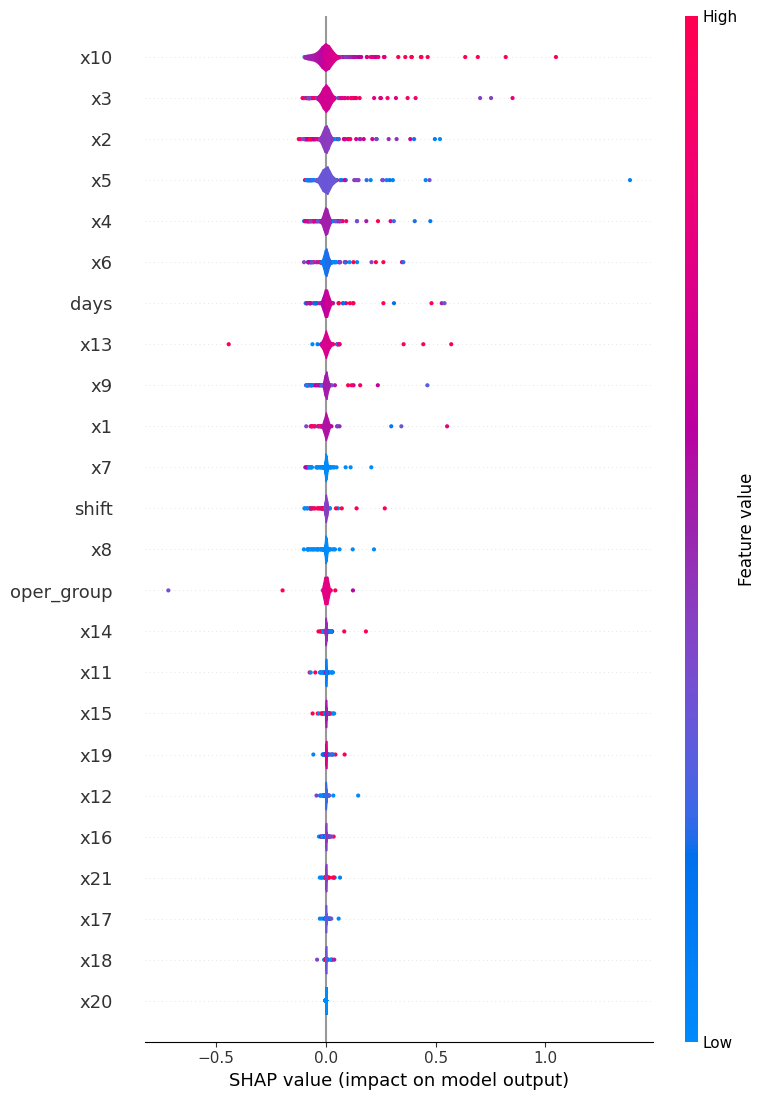

In [71]:
shap.summary_plot(shap_values, sampled_test, feature_names=input_columns, max_display=len(input_columns), plot_type = 'violin')